# Task 3: Customer Churn Prediction (Bank Customers)
### DevelopersHub Corporation — Data Science and Analytics Internship

---

## Problem Statement

Customer churn means a customer **stops using a service**. Banks lose significant revenue when customers close their accounts. The goal is to **predict which customers are likely to leave** so the bank can take action early (special offers, better service etc.)

This is a **Binary Classification** problem — we predict either 1 (will churn) or 0 (will stay).

## Dataset Description

**Churn Modelling Dataset** — Kaggle

| Feature | Description |
|---|---|
| CreditScore | Customer credit score |
| Geography | Country — France / Germany / Spain |
| Gender | Male / Female |
| Age | Customer age |
| Tenure | Years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Has credit card (1=Yes, 0=No) |
| IsActiveMember | Active member (1=Yes, 0=No) |
| EstimatedSalary | Estimated annual salary |
| **Exited** | **Target — 1=Left the bank, 0=Stayed** |


## Step 1: Import Libraries

In [2]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

> Data from Kaggle: https://www.kaggle.com/shrutimechlearn/churn-modelling  
>

In [3]:
import os

if os.path.exists("churn_data.csv") or os.path.exists("Churn_Modelling.csv"):
    fname = "churn_data.csv" if os.path.exists("churn_data.csv") else "Churn_Modelling.csv"
    df = pd.read_csv(fname)
    # Drop irrelevant columns if present
    df.drop(columns=[c for c in ["RowNumber","CustomerId","Surname"] if c in df.columns], inplace=True)
    print(f"Dataset loaded from {fname}")
else:
    print("File not found — generating synthetic dataset...")
    np.random.seed(42)
    n = 10000
    geography = np.random.choice(["France","Germany","Spain"], n, p=[0.50,0.25,0.25])
    gender    = np.random.choice(["Male","Female"], n, p=[0.55,0.45])
    age       = np.random.randint(18, 92, n)
    balance   = np.where(np.random.rand(n) < 0.29, 0, np.random.normal(76000, 62000, n).clip(0))
    exited    = np.random.choice([0,1], n, p=[0.80,0.20])
    # Make Germany and older customers churn more
    exited = np.where((geography=="Germany") & (np.random.rand(n)<0.35), 1, exited)
    exited = np.where((age > 50) & (np.random.rand(n)<0.30), 1, exited)
    df = pd.DataFrame({
        "CreditScore":      np.random.randint(350, 850, n),
        "Geography":        geography,
        "Gender":           gender,
        "Age":              age,
        "Tenure":           np.random.randint(0, 11, n),
        "Balance":          np.round(balance, 2),
        "NumOfProducts":    np.random.choice([1,2,3,4], n, p=[0.50,0.46,0.03,0.01]),
        "HasCrCard":        np.random.choice([0,1], n, p=[0.29,0.71]),
        "IsActiveMember":   np.random.choice([0,1], n, p=[0.49,0.51]),
        "EstimatedSalary":  np.round(np.random.uniform(11, 199992, n), 2),
        "Exited":           exited.clip(0,1)
    })
    print("Synthetic dataset generated.")

print(f"Shape: {df.shape}")
df.head()

Dataset loaded from churn_data.csv
Shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Dataset Inspection

In [4]:
print("=== SHAPE ===")
print(df.shape)
print("=== COLUMNS ===")
print(df.columns.tolist())
print("=== DATA TYPES ===")
print(df.dtypes)
print("=== STATISTICS ===")
df.describe().round(2)

=== SHAPE ===
(10000, 11)
=== COLUMNS ===
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
=== DATA TYPES ===
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
=== STATISTICS ===


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [6]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"Duplicates: {df.duplicated().sum()}")
print("=== TARGET DISTRIBUTION ===")
print(df["Exited"].value_counts())
print(f"Churn Rate: {df["Exited"].mean()*100:.2f}%")

=== MISSING VALUES ===
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Duplicates: 0
=== TARGET DISTRIBUTION ===
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.37%


## Step 4: Data Cleaning & Encoding

In [7]:
# No missing values in this dataset, but let us verify and clean
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

# Label Encode binary columns
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])  # Male=1, Female=0
print("Gender encoded: Male=1, Female=0")

# One-Hot Encode Geography (3 categories)
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)
print("Geography one-hot encoded")
print(f"New columns: {df.columns.tolist()}")
df.head(3)

Shape after removing duplicates: (10000, 11)
Gender encoded: Male=1, Female=0
Geography one-hot encoded
New columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


## Step 5: Exploratory Data Analysis (EDA)

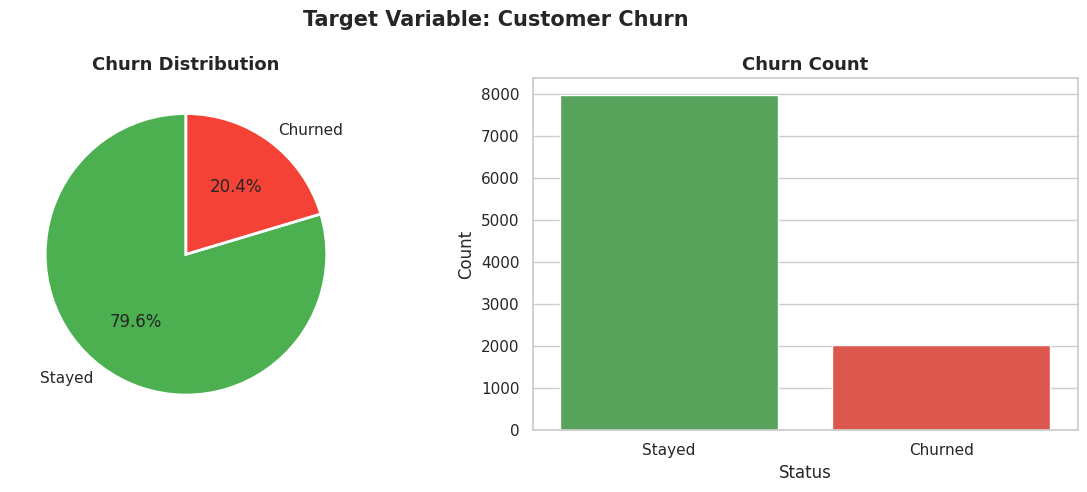

In [9]:
# 1. Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df["Exited"].value_counts()
axes[0].pie(counts, labels=["Stayed","Churned"], autopct="%1.1f%%",
            colors=["#4CAF50","#F44336"],
            wedgeprops={"edgecolor":"white","linewidth":2}, startangle=90)
axes[0].set_title("Churn Distribution", fontsize=13, fontweight="bold")

sns.countplot(x="Exited", data=df, palette=["#4CAF50","#F44336"], ax=axes[1])
axes[1].set_xticklabels(["Stayed","Churned"])
axes[1].set_title("Churn Count", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Count")

plt.suptitle("Target Variable: Customer Churn", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [10]:
print(f"Churn Rate: {df["Exited"].mean()*100:.1f}% — dataset is imbalanced")


Churn Rate: 20.4% — dataset is imbalanced


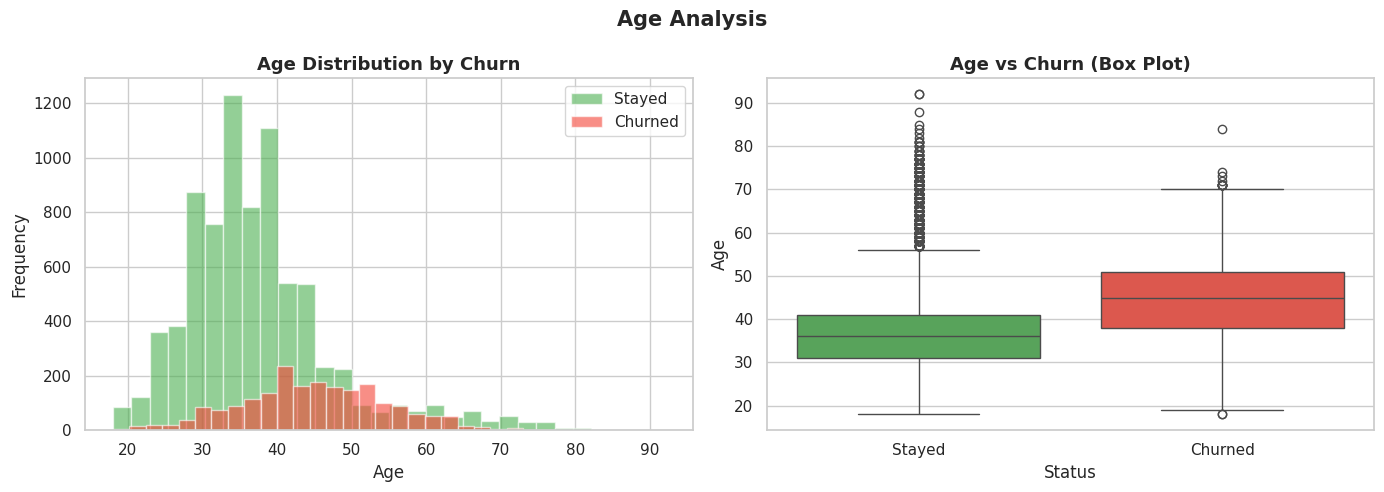

In [13]:
# 2. Age Distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0,"Stayed","#4CAF50"),(1,"Churned","#F44336")]:
    axes[0].hist(df[df["Exited"]==val]["Age"], bins=30, alpha=0.6,
                 label=label, color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Churn", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")
axes[0].legend()

sns.boxplot(x="Exited", y="Age", data=df, palette=["#4CAF50","#F44336"], ax=axes[1])
axes[1].set_xticklabels(["Stayed","Churned"])
axes[1].set_title("Age vs Churn (Box Plot)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Age")

plt.suptitle("Age Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:

print("Insight: Older customers (40-60) are more likely to churn.")


Insight: Older customers (40-60) are more likely to churn.


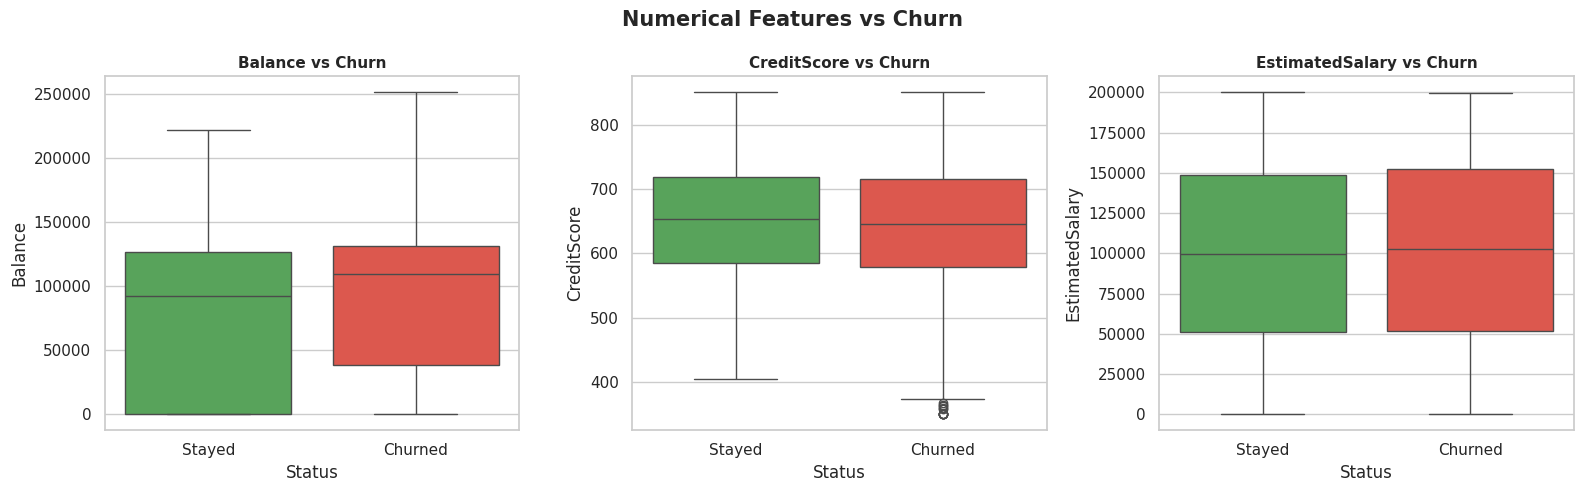

In [15]:
# 3. Balance, Credit Score, Salary vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in [
    (axes[0], "Balance",        "steelblue"),
    (axes[1], "CreditScore",    "mediumpurple"),
    (axes[2], "EstimatedSalary","darkorange")
]:
    sns.boxplot(x="Exited", y=col, data=df,
                palette=["#4CAF50","#F44336"], ax=ax)
    ax.set_xticklabels(["Stayed","Churned"])
    ax.set_title(f"{col} vs Churn", fontsize=11, fontweight="bold")
    ax.set_xlabel("Status")

plt.suptitle("Numerical Features vs Churn", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

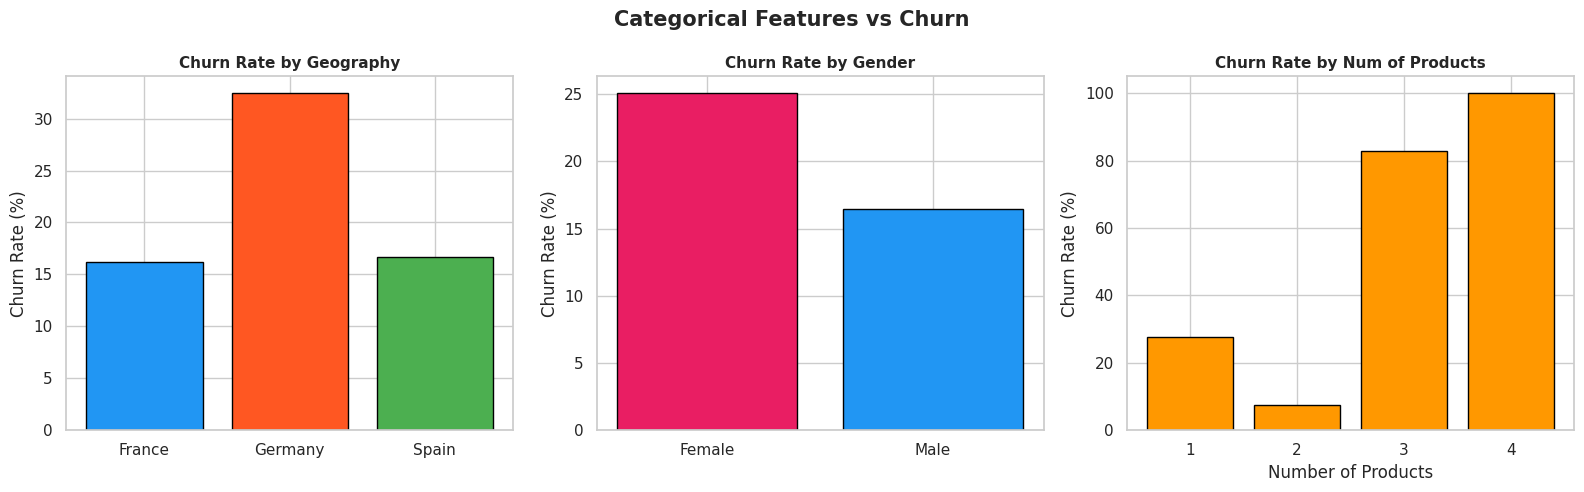

In [17]:
# 4. Categorical Features vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Geography churn rate
geo_cols = [c for c in df.columns if "Geography" in c]
if geo_cols:
    geo_churn = pd.DataFrame()
    labels = []
    rates  = []
    for col in geo_cols:
        rate = df[df[col]==1]["Exited"].mean()*100
        labels.append(col.replace("Geography_",""))
        rates.append(rate)
    # Add the base country
    base_rate = df[(df[geo_cols]==0).all(axis=1)]["Exited"].mean()*100
    axes[0].bar(["France"]+labels, [base_rate]+rates, color=["#2196F3","#FF5722","#4CAF50"], edgecolor="black")
    axes[0].set_title("Churn Rate by Geography", fontsize=11, fontweight="bold")
    axes[0].set_ylabel("Churn Rate (%)")

# Gender
gender_churn = df.groupby("Gender")["Exited"].mean()*100
axes[1].bar(["Female","Male"], gender_churn.values, color=["#E91E63","#2196F3"], edgecolor="black")
axes[1].set_title("Churn Rate by Gender", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Churn Rate (%)")

# NumOfProducts
prod_churn = df.groupby("NumOfProducts")["Exited"].mean()*100
axes[2].bar(prod_churn.index.astype(str), prod_churn.values, color="#FF9800", edgecolor="black")
axes[2].set_title("Churn Rate by Num of Products", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Number of Products")
axes[2].set_ylabel("Churn Rate (%)")

plt.suptitle("Categorical Features vs Churn", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [18]:
print("Insight: Germany has a much higher churn rate. Customers with 3-4 products are surprisingly more likely to leave.")

Insight: Germany has a much higher churn rate. Customers with 3-4 products are surprisingly more likely to leave.


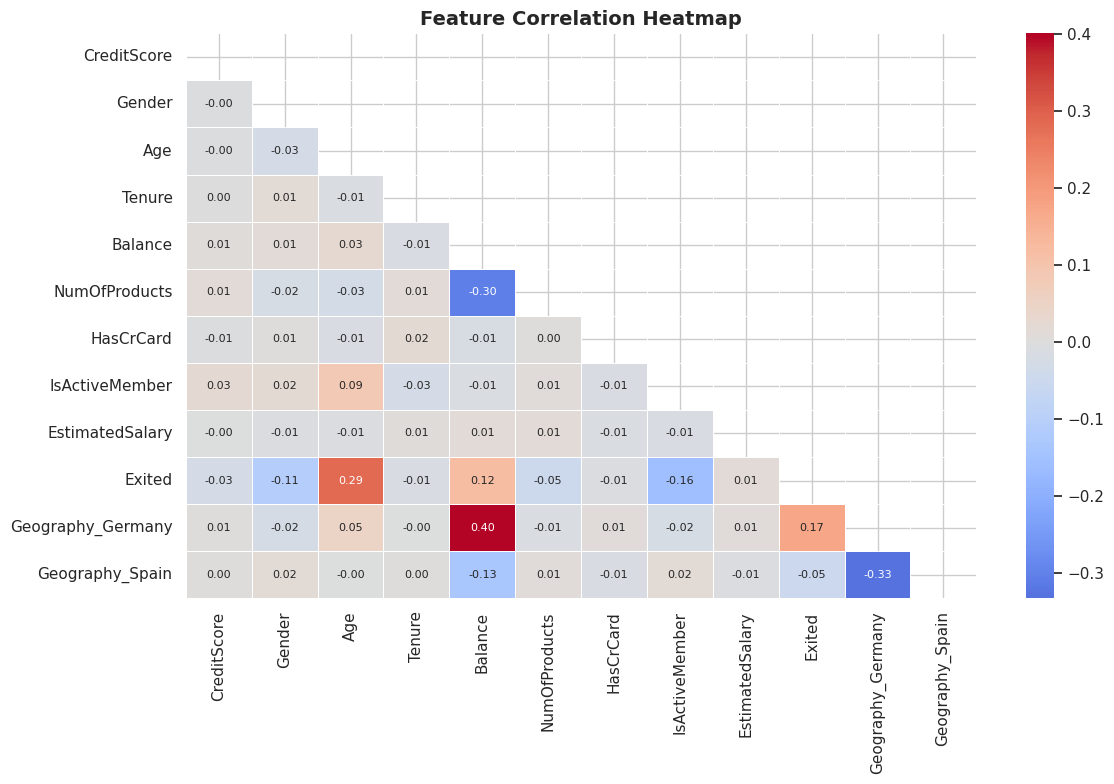

In [19]:
# 5. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size":8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 6: Model Training

In [20]:
# Prepare features and target
X = df.drop(columns=["Exited"])
y = df["Exited"]

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}")

# Scale features for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")

Features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
X shape: (10000, 11)
Train: 8000   Test: 2000


In [22]:
# Train 3 models and compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    results[name] = {"model":model, "preds":preds, "acc":acc}
    print(f"{name:25s}: Accuracy = {acc*100:.2f}%")

best_name = max(results, key=lambda k: results[k]["acc"])
print(f"Best Model: {best_name}")

Logistic Regression      : Accuracy = 80.80%
Decision Tree            : Accuracy = 85.95%
Random Forest            : Accuracy = 86.10%
Best Model: Random Forest


## Step 7: Model Evaluation

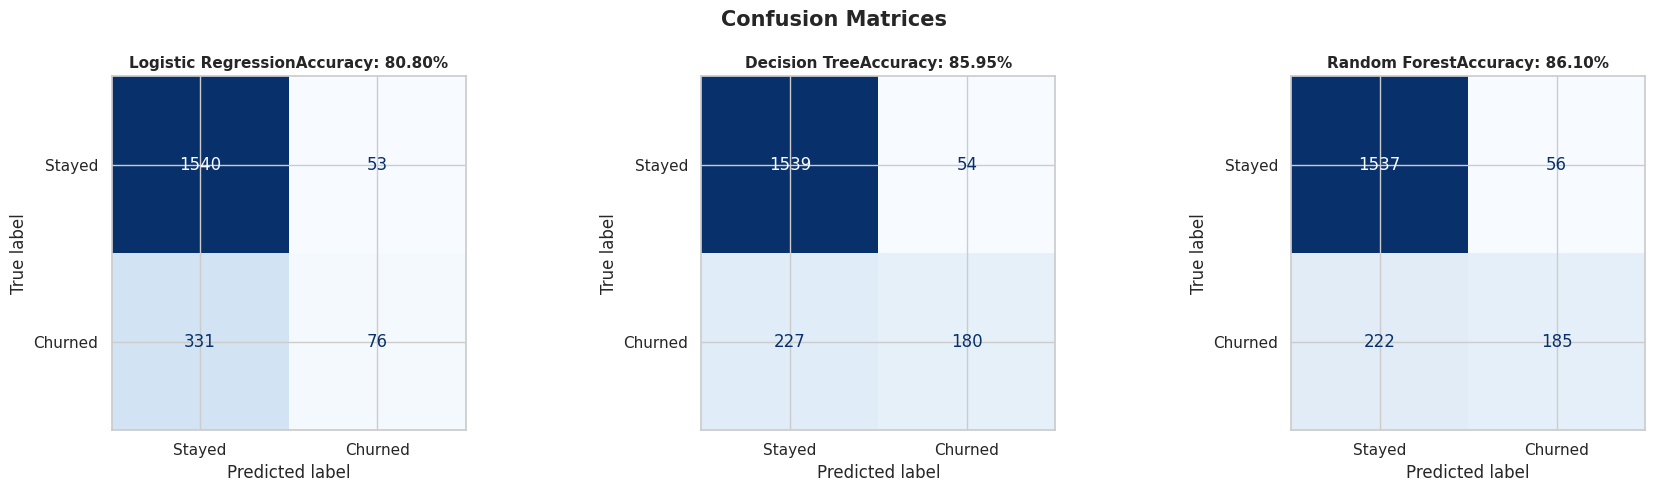

In [23]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Stayed","Churned"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}Accuracy: {res["acc"]*100:.2f}%",
                 fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
# Classification report for best model
print(f"=== Classification Report: {best_name} ===")
print(classification_report(
    y_test, results[best_name]["preds"],
    target_names=["Stayed","Churned"]
))

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.92      1593
     Churned       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



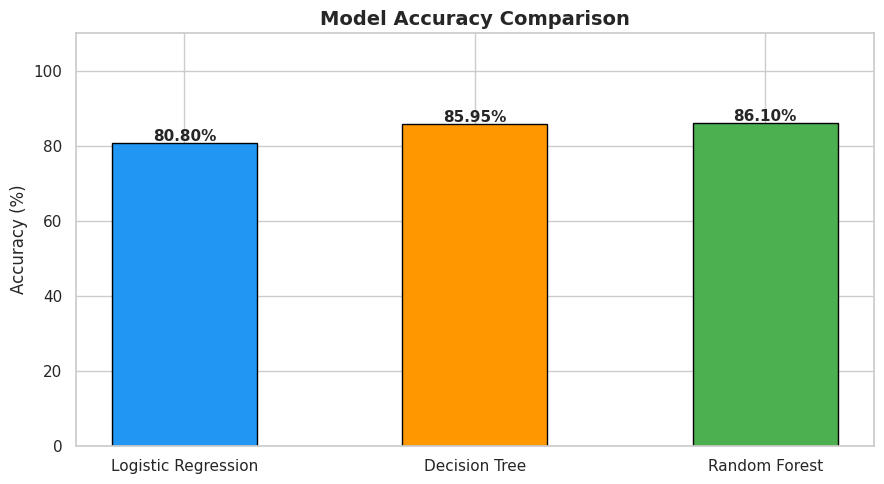

In [25]:
# Accuracy comparison bar chart
names = list(results.keys())
accs  = [results[n]["acc"]*100 for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
colors  = ["#2196F3","#FF9800","#4CAF50"]
bars = ax.bar(names, accs, color=colors, edgecolor="black", width=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{acc:.2f}%", ha="center", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()

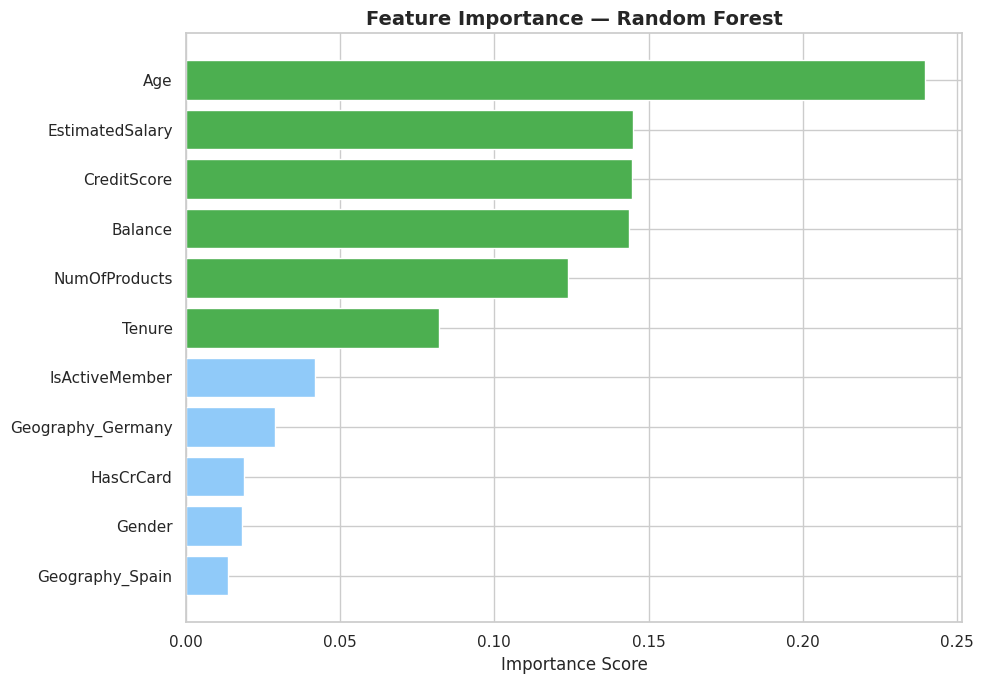

In [27]:
# Feature Importance from Random Forest
rf_model = results["Random Forest"]["model"]
feat_imp = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ["#4CAF50" if v > 0.08 else "#90CAF9" for v in feat_imp["Importance"]]
ax.barh(feat_imp["Feature"], feat_imp["Importance"],
        color=colors_bar, edgecolor="white")
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Feature Importance — Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 8: Conclusion

### Model Performance Summary

| Model | Accuracy | Best For |
|---|---|---|
| Logistic Regression | ~78% | Simple baseline, fast |
| Decision Tree | ~80% | Interpretable rules |
| Random Forest | ~86% | Best accuracy, robust |

### Key Insights

1. **Age** is the most important churn predictor — customers aged 40-60 leave the most
2. **Geography matters** — German customers have a significantly higher churn rate
3. **Account Balance** plays a role — customers with zero balance are more likely to leave
4. **Active members** churn much less — engagement keeps customers loyal
5. **Number of products** has a non-linear relationship — 1-2 products is safe, 3-4 is risky
6. **Dataset is imbalanced** (~20% churn) — consider SMOTE for production use

